# Combined Plot Examples

This notebook shows how to combine different `pythermalcomfort.plots.matplotlib` chart types with each other and with standard Matplotlib code. These are practical recipes, not API references — see `threshold_plot.ipynb`, `summary_plot.ipynb`, `adaptive_plot.ipynb`, and `psychrometric_plot.ipynb` for full API coverage.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

from pythermalcomfort.models import adaptive_ashrae, pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import AdaptivePlot, SummaryPlot, ThresholdPlot

## 1. Comfort Zone + Measurement Summary

Place a `ThresholdPlot` and a `SummaryPlot` side by side to show both where conditions fall within the comfort space and how much time was spent in each region. The two charts share the same region definition, so colours and boundaries match automatically.

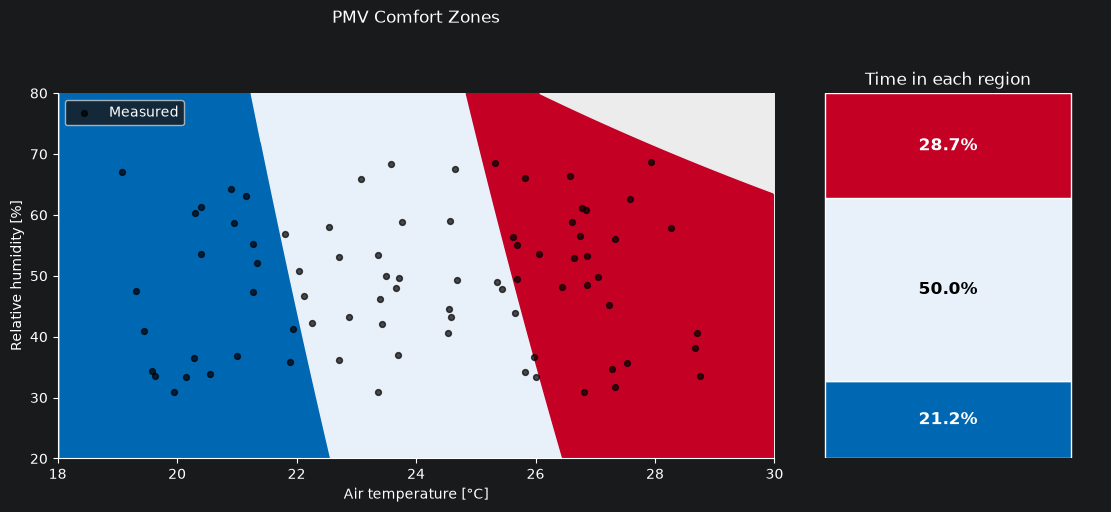

In [2]:
# Measured dataset
rng = np.random.default_rng(42)
n = 80
df = pd.DataFrame(
    {
        "tdb": rng.uniform(19, 29, n),
        "rh": rng.uniform(30, 70, n),
        "tr": rng.uniform(19, 30, n),
        "vr": np.full(n, 0.1),
        "met": np.full(n, 1.2),
        "clo": rng.uniform(0.4, 0.9, n),
        "wme": np.zeros(n),
    }
)
df["pmv"] = [
    pmv_ppd_iso(
        tdb=r.tdb, tr=r.tr, vr=r.vr, rh=r.rh, met=r.met, clo=r.clo, wme=r.wme
    ).pmv
    for r in df.itertuples(index=False)
]

thresholds = [-0.5, 0.5]

fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [2.8, 1.2]},
)

# Left: threshold chart with measured points overlaid
tp = (
    ThresholdPlot(model_func=pmv_ppd_iso)
    .set_x_axis(name="tdb", min_val=18.0, max_val=30.0)
    .set_y_axis(name="rh", min_val=20.0, max_val=80.0)
    .set_params(vr=0.10, met=1.2, clo=0.65, wme=0.0)
    .set_regions(output="pmv", thresholds=thresholds)
    .plot(ax=ax0, title="PMV Comfort Zones")
)
tp.ax.scatter(
    df["tdb"], df["rh"], color="black", s=18, zorder=5, alpha=0.7, label="Measured"
)
tp.ax.legend(loc="upper left")
tp.ax.set_xlabel("Air temperature [°C]")
tp.ax.set_ylabel("Relative humidity [%]")

# Right: summary bar showing time share per region
(
    SummaryPlot(df=df)
    .set_regions(output="pmv", thresholds=thresholds, labels=[])
    .plot(ax=ax1, vertical=True, title="Time in each region", legend=False)
)

plt.show()

## 2. Adaptive Chart with Seasonal Measured Data

Plot measured operative temperatures on top of an adaptive comfort chart. Colour the points by outdoor temperature to show seasonal variation.

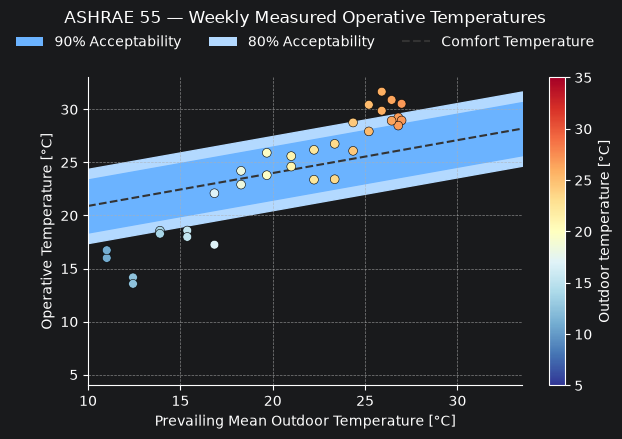

In [3]:
# Synthetic seasonal dataset (one point per week across a year)
weeks = 52
t_out = 15 + 12 * np.sin(np.linspace(-np.pi / 2, 3 * np.pi / 2, weeks))
t_op = t_out + rng.normal(3.5, 1.5, weeks)

result = (
    AdaptivePlot(model_func=adaptive_ashrae)
    .set_params(v=0.2)
    .plot(title="ASHRAE 55 — Weekly Measured Operative Temperatures")
)

sc = result.ax.scatter(
    t_out,
    t_op,
    c=t_out,
    cmap="RdYlBu_r",
    vmin=5,
    vmax=35,
    s=40,
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
)
plt.colorbar(sc, ax=result.ax, label="Outdoor temperature [°C]")
plt.show()

## 3. PMV Time Series with Comfort Band

Shows how PMV evolves over a day or monitoring period. The shaded band marks the ±0.5 comfort interval.

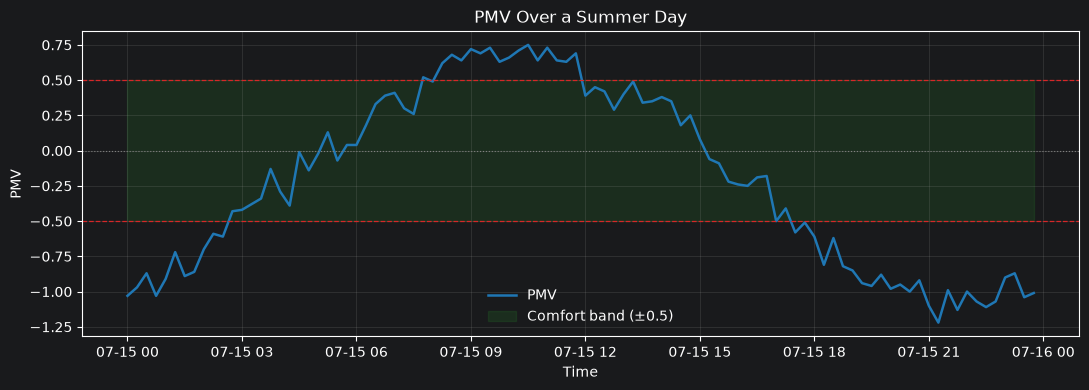

In [4]:
n = 96
ts = pd.date_range("2026-07-15", periods=n, freq="15min")
tdb = 24 + 3 * np.sin(np.linspace(0, 2 * np.pi, n) - 1.2) + rng.normal(0, 0.3, n)
rh = 52 + 8 * np.sin(np.linspace(0, 2 * np.pi, n) + 0.5) + rng.normal(0, 1.0, n)

pmv_ts = [
    pmv_ppd_iso(tdb=t, tr=t, vr=0.1, rh=r, met=1.2, clo=0.5, wme=0.0).pmv
    for t, r in zip(tdb, rh, strict=False)
]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts, pmv_ts, lw=1.8, color="#1f77b4", label="PMV")
ax.fill_between(ts, -0.5, 0.5, color="#2ca02c", alpha=0.15, label="Comfort band (±0.5)")
ax.axhline(0.5, color="#d62728", ls="--", lw=0.9)
ax.axhline(-0.5, color="#d62728", ls="--", lw=0.9)
ax.axhline(0.0, color="gray", ls=":", lw=0.8)
ax.set_title("PMV Over a Summer Day")
ax.set_ylabel("PMV")
ax.set_xlabel("Time")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. UTCI Category Frequency

Classify UTCI values into the official thermal-stress categories and display how often each category occurred in a dataset. Uses `pd.cut` with the standard UTCI thresholds.

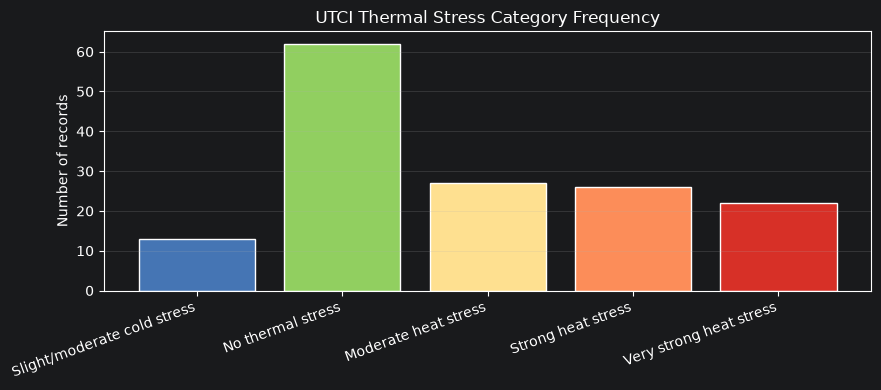

In [5]:
# Synthetic outdoor monitoring dataset
m = 150
tdb_out = rng.uniform(8, 40, m)
tout = pd.DataFrame(
    {
        "tdb": tdb_out,
        # Mean radiant temperature tracks air temperature outdoors, rising well
        # above it in sun. Drawing the two independently would let tr - tdb
        # fall outside UTCI's -30 to +70 degC limit.
        "tr": tdb_out + rng.uniform(-4, 12, m),
        # UTCI is defined from 0.5 m/s upward.
        "v": rng.uniform(0.5, 4.0, m),
        "rh": rng.uniform(20, 85, m),
    }
)
tout["utci"] = [
    utci(tdb=r.tdb, tr=r.tr, v=r.v, rh=r.rh).utci for r in tout.itertuples(index=False)
]

bins = [-np.inf, 9, 26, 32, 38, np.inf]
labels = [
    "Slight/moderate cold stress",
    "No thermal stress",
    "Moderate heat stress",
    "Strong heat stress",
    "Very strong heat stress",
]
colors = ["#4575b4", "#91cf60", "#fee090", "#fc8d59", "#d73027"]
tout["category"] = pd.cut(tout["utci"], bins=bins, labels=labels, right=False)
counts = tout["category"].value_counts().reindex(labels, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
ax.set_title("UTCI Thermal Stress Category Frequency")
ax.set_ylabel("Number of records")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Annual Comfort Heatmap + Summary

A heatmap can show the hour and day when a comfort category occurred, while `SummaryPlot` reports the share of observations in each category. The first cell creates synthetic hourly PMV values. Replace `df_annual` with your own hourly DataFrame for one calendar year: it only needs a `DatetimeIndex` and a `pmv` column. The second cell classifies, reshapes, and plots those values with standard Matplotlib.

In [6]:
# Create synthetic hourly PMV measurements for one year.
index = pd.date_range("2025-01-01", "2026-01-01", freq="h", inclusive="left")
day = index.dayofyear.to_numpy()
hour = index.hour.to_numpy()
df_annual = pd.DataFrame(
    {
        "pmv": (
            0.65 * np.sin(2 * np.pi * (day - 172) / 365)
            + 0.35 * np.sin(2 * np.pi * (hour - 8) / 24)
            + np.random.default_rng(7).normal(0, 0.12, len(index))
        )
    },
    index=index,
)

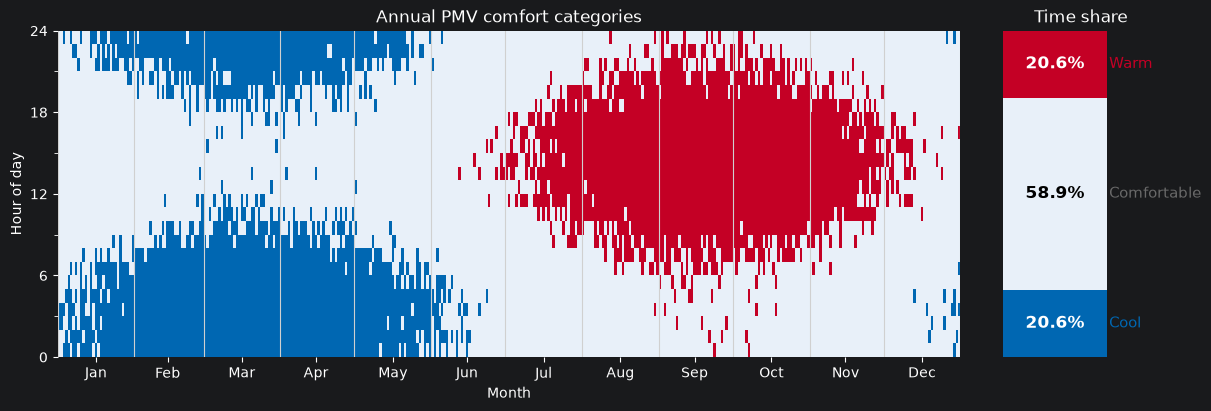

In [7]:
# Plot df_annual, replacing it with your own hourly DataFrame when needed.
year = int(df_annual.index.year[0])
n_days = int(df_annual.index.dayofyear.max())
thresholds = [-0.5, 0.5]
labels = ["Cool", "Comfortable", "Warm"]
# Use the default cool-neutral-warm palette throughout the paired charts.
colors = ["#86AEC8", "#F1F3F2", "#D88B7B"]
categories = pd.cut(
    df_annual["pmv"],
    bins=[-np.inf, *thresholds, np.inf],
    labels=labels,
)

codes = categories.cat.codes.replace(-1, np.nan)
heatmap = (
    pd.DataFrame(
        {
            "day": df_annual.index.dayofyear,
            "hour": df_annual.index.hour,
            "category": codes,
        }
    )
    .pivot(index="hour", columns="day", values="category")
    .reindex(index=range(24), columns=range(1, n_days + 1))
)

fig, (ax_heatmap, ax_summary) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [5, 1], "wspace": 0.05},
    constrained_layout=True,
)

ax_heatmap.pcolormesh(
    np.arange(0.5, n_days + 1.5),
    np.arange(25),
    heatmap.to_numpy(),
    cmap=ListedColormap(colors),
    norm=BoundaryNorm(np.arange(-0.5, len(labels) + 0.5), len(labels)),
)
month_starts = pd.date_range(f"{year}-01-01", f"{year + 1}-01-01", freq="MS")[:-1]
month_starts = month_starts[month_starts.dayofyear <= n_days]
month_ends = month_starts + pd.offsets.MonthEnd()
month_midpoints = month_starts + (month_ends - month_starts) / 2
ax_heatmap.set(
    title="Annual PMV comfort categories",
    xlabel="Month",
    ylabel="Hour of day",
    ylim=(0, 24),
    xticks=month_midpoints.dayofyear,
    xticklabels=month_starts.strftime("%b"),
)
ax_heatmap.set_yticks([0, 6, 12, 18, 24])
ax_heatmap.set_yticks([3, 9, 15, 21], minor=True)
ax_heatmap.tick_params(axis="y", which="minor", length=3)
for boundary in np.append(month_starts.dayofyear - 0.5, n_days + 0.5):
    ax_heatmap.axvline(boundary, color="#d0d0d0", linewidth=0.8)
for spine in ax_heatmap.spines.values():
    spine.set_visible(False)

valid = categories.notna()
(
    SummaryPlot(df=df_annual.loc[valid])
    .set_categories(categories=categories.loc[valid], labels=labels, colors=colors)
    .plot(
        ax=ax_summary,
        vertical=True,
        legend=False,
        title="Time share",
        bar_kws={"edgecolor": "none"},
    )
)

plt.show()